In [1]:
import torch
import sys, os
import time

sys.path.append("./../../")

from pushing_dynamics import pusher_slider_sys
from src.ttts import TTTS
torch.set_default_dtype(torch.float64)

from robot_utils import PlanarManipulator, PlanarManipulatorCost, Point2PointMotion

cur_path = os.path.abspath(os.getcwd())

%matplotlib inline
%load_ext autoreload

%autoreload 2


device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

pybullet build time: May 20 2022 19:43:01


device(type='cuda')

In [2]:
w = 0.5

state_max_c = torch.tensor([w,w,torch.pi, -0.065, 0.06]).to(device) # (s_x, s_y, s_theta, p_x, p_y) 
state_min_c =  torch.tensor([-w,-w,-torch.pi, -0.1, -0.06]).to(device)

state_max = torch.tensor([w,w,torch.pi, -0.065, 0.06, 3]).to(device) # (s_x, s_y, s_theta, p_x, p_y, face_id) 
state_min =  torch.tensor([-w,-w,-torch.pi, -0.1, -0.06, 0]).to(device)


n = 50
n_state = 50
n_action = 30

vx = 1; vy=1

action_max_c = torch.tensor([vx, vy]).to(device) # (p_ddx, p_ddy)
action_min_c = torch.tensor([0, -vy]).to(device)
action_max =  torch.tensor([vx,vy,3]).to(device)
action_min = torch.tensor([0,-vy,0]).to(device)


In [3]:

T=0.5
dt = 0.01
K=2
n_switches = 4 #number of face switch

domain_state =  [torch.linspace(state_min_c[i],state_max_c[i],n_state).to(device) for i in range(len(state_max_c))]  +[torch.tensor([0.,1.,2.,3.]).to(device)]
domain_action = []
for i in range(n_switches):
    domain_action.append(torch.tensor([0., 1., 2., 3.]).to(device))
for j in range(K):
    for i in range(len(action_max_c)):
        domain_action.append(torch.linspace(action_min_c[i], action_max_c[i], n_action).to(device))



bounds = [action_min_c, action_max_c]
p2p_motion = Point2PointMotion(T=T, n=len(action_max_c),dt=dt, K=K, basis='bs2',bounds=bounds, device=device)


p_target = torch.tensor([0., 0., 0.]).view(1,-1).to(device)

# dim=5
min_state = torch.tensor([x[0] for x in domain_state]).to(device)
max_state = torch.tensor([x[-1] for x in domain_state]).to(device)

dyn_system =  pusher_slider_sys(p2p=p2p_motion,n_switches=n_switches, state_min=min_state, state_max=max_state,
                                p_target=p_target,T=T, dt=dt, device=device)


In [4]:

n_test = 1
dim_state = len(domain_state)
init_state = torch.empty((n_test,dim_state))
for i in range(dim_state):
    init_state[:,i] = state_min[i] + torch.rand(n_test).clip(0.25,0.75).to(device)*(state_max[i]-state_min[i])
init_state = init_state.to(device)
init_state = torch.tensor([[ 0.2500,  0.2500, -1.5708, -0.0738,  0.0106,  0.0000]]).to(device) #multi-modalsolution
# init_state = torch.tensor([[-0.25, 0.25, torch.pi/2, -0.065, 0., 0.]]).to(device)
# init_state = torch.tensor([[0.25, -0.25, torch.pi/2, -0.065, 0., 0.]]).to(device)
init_state[:, -1] = torch.zeros_like(init_state[:, -1]).to(device)

print('init_state: ', init_state)

init_state:  tensor([[ 0.2500,  0.2500, -1.5708, -0.0738,  0.0106,  0.0000]],
       device='cuda:0')


In [5]:
evaluate_time = [0.0]

def objective_func(x):
    t0 = time.time()
    state, cost, traj, traj_actions = dyn_system.forward_rollout(init_state, x)
    evaluate_time[0] += time.time() - t0
    return 1*torch.exp(-(cost))


ttts = TTTS(func = objective_func, domain = domain_action, value_k=5, visit_k=5,
            file_name='pusher_slider', max_tt=50, cross_max_iter=3,kickrank=20,
             warm_start=False, verbose=False, save_tt=True)

evaluate_time[0] = 0.0
st = time.time()
sol = ttts.iterate(max_iters= 3, param_C=3) # K x n
t_wall = time.time() - st
t_net = t_wall - evaluate_time[0]
print(f'Time: wall={t_wall:.2f}s  net={t_net:.2f}s')




mcts-iters: 1, top-k values: [0.801808525029827, 0.7978256035813598, 0.795195075353904, 0.7942975834966741, 0.7849050095129873]
mcts-iters: 2, top-k values: [0.8266708692607433, 0.824969854930415, 0.817713495128253, 0.81443543781171, 0.8117483514043112]
mcts-iters: 3, top-k values: [0.8453518791156853, 0.8317897515350032, 0.8304348679453334, 0.8302755184125372, 0.8302059940169269]
Time: wall=9.62s  net=1.42s


In [7]:
final_sol = ttts.parallel_cmaes_gpu(initial_guesses=sol[:, n_switches:], popsize=25, num_iterations=20, task_var=sol[:, :n_switches])

#combined solution
# final_sol = torch.cat((sol[:, :n_switches], sol_2), dim=1)


final_state, cost, traj, traj_actions = dyn_system.forward_rollout(init_state, final_sol)
print('cost: ', cost)
print('final_state: ', final_state)


#CMA-ES, Iteration: 20, Max values: 0.9346315621488839
cost:  tensor([0.0676, 0.0682, 0.0694, 0.0696, 0.0701], device='cuda:0')
final_state:  tensor([[ 2.3738e-04, -1.1419e-05,  4.5384e-03, -6.3900e-02, -2.8610e-04,
          3.0000e+00],
        [-1.1280e-03, -2.5149e-04,  2.6207e-03, -6.3900e-02,  1.5474e-03,
          3.0000e+00],
        [-2.6459e-03,  1.2775e-03,  3.0433e-03, -6.4015e-02,  3.5380e-03,
          3.0000e+00],
        [ 7.0633e-07, -5.4827e-04,  2.2613e-03, -6.3900e-02,  2.3192e-03,
          2.0000e+00],
        [-8.3260e-04,  3.0288e-04, -4.2166e-03, -6.3900e-02,  2.3819e-03,
          2.0000e+00]], device='cuda:0')


In [8]:
traj.shape, traj_actions.shape

(torch.Size([5, 59, 6]), torch.Size([5, 58, 3]))

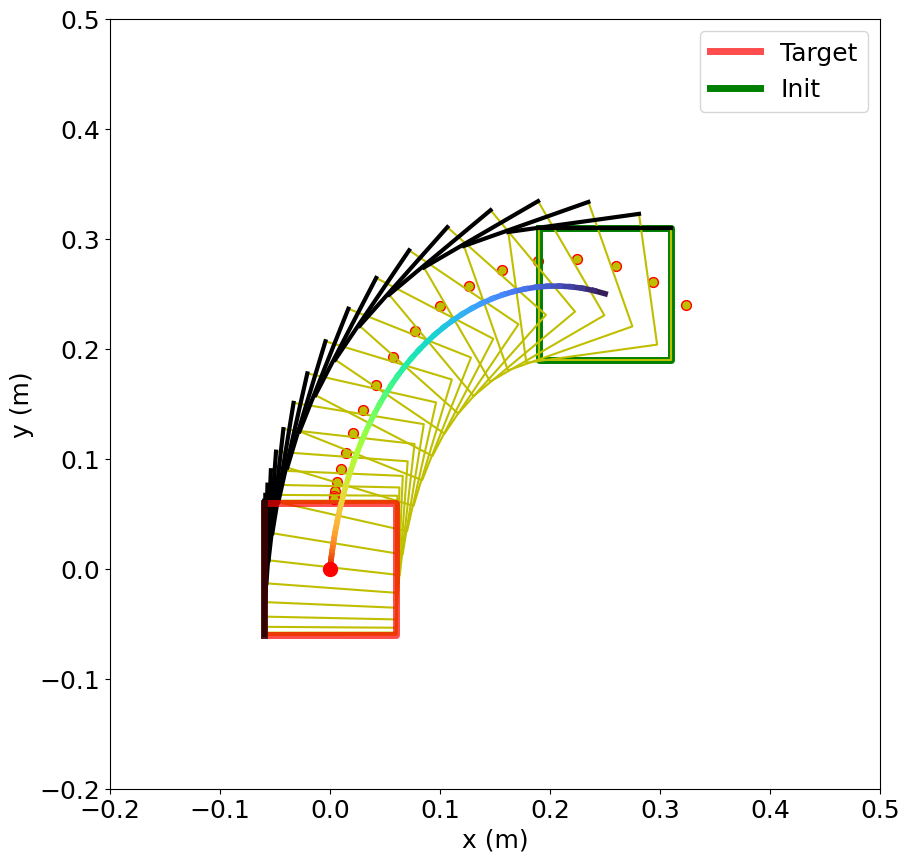

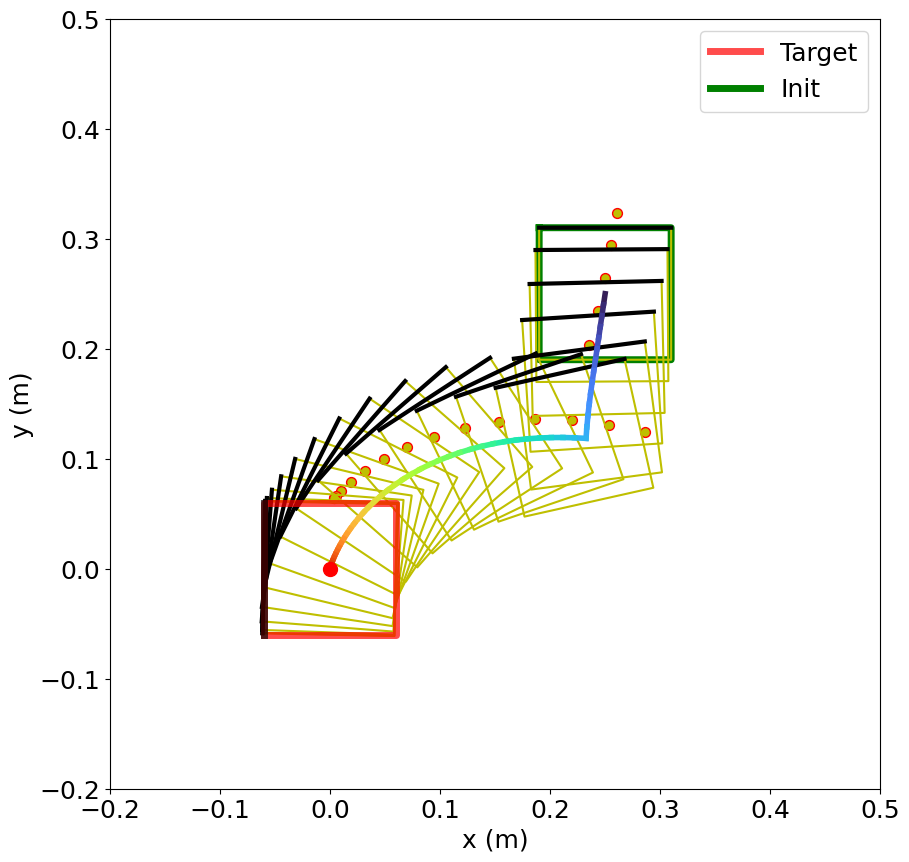

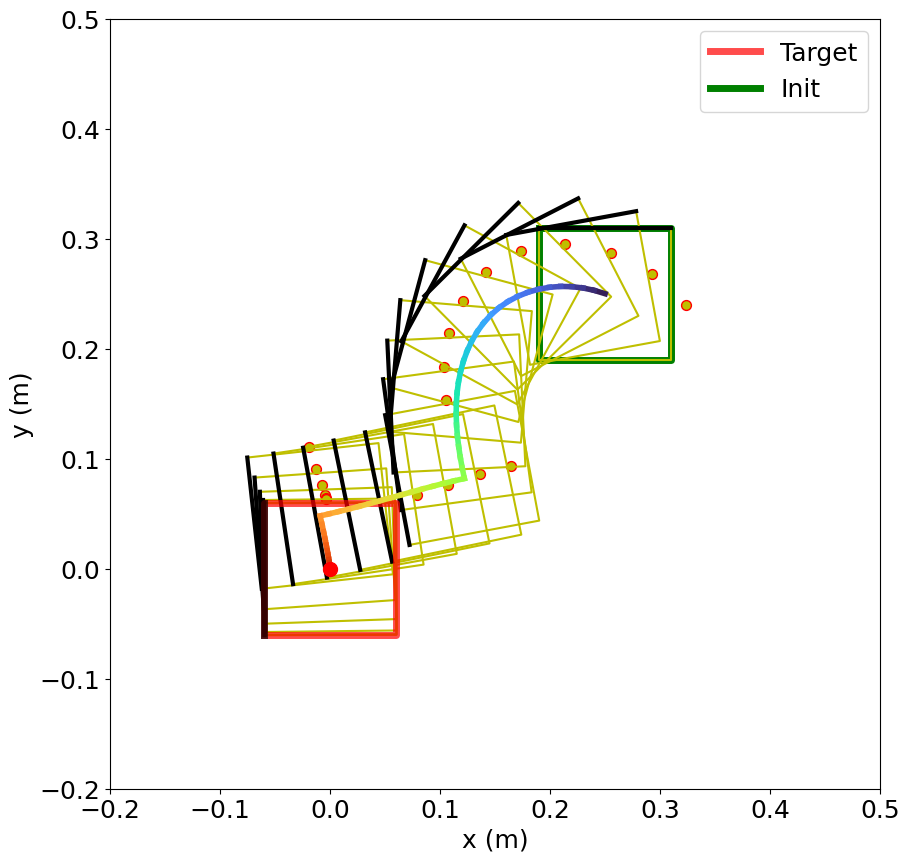

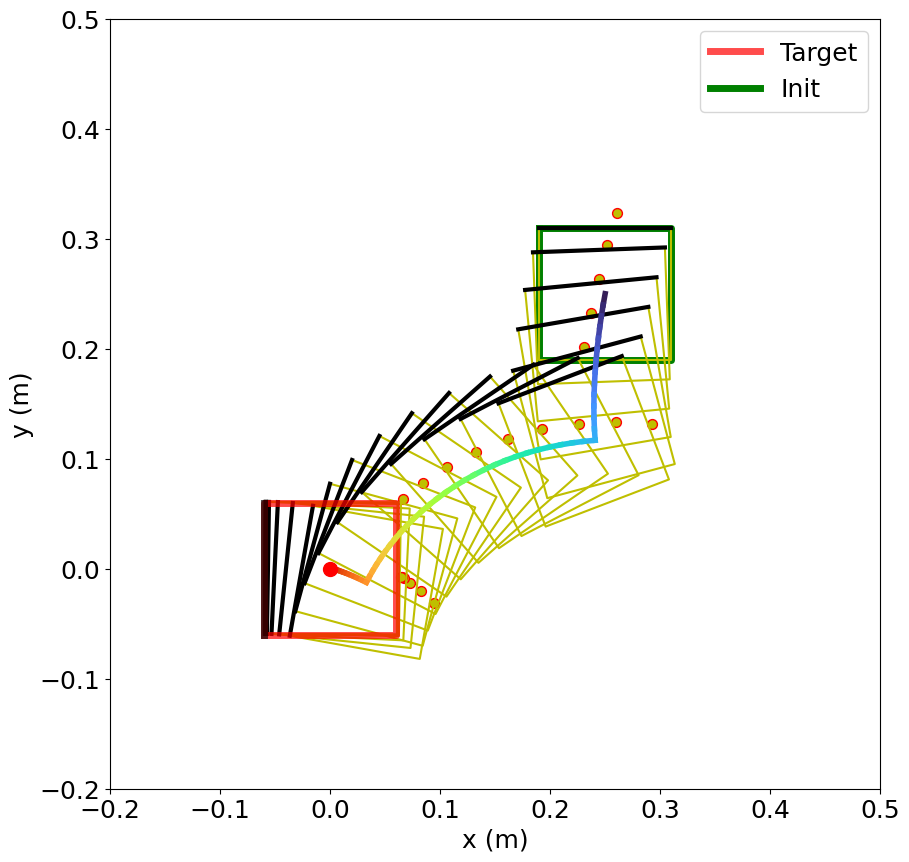

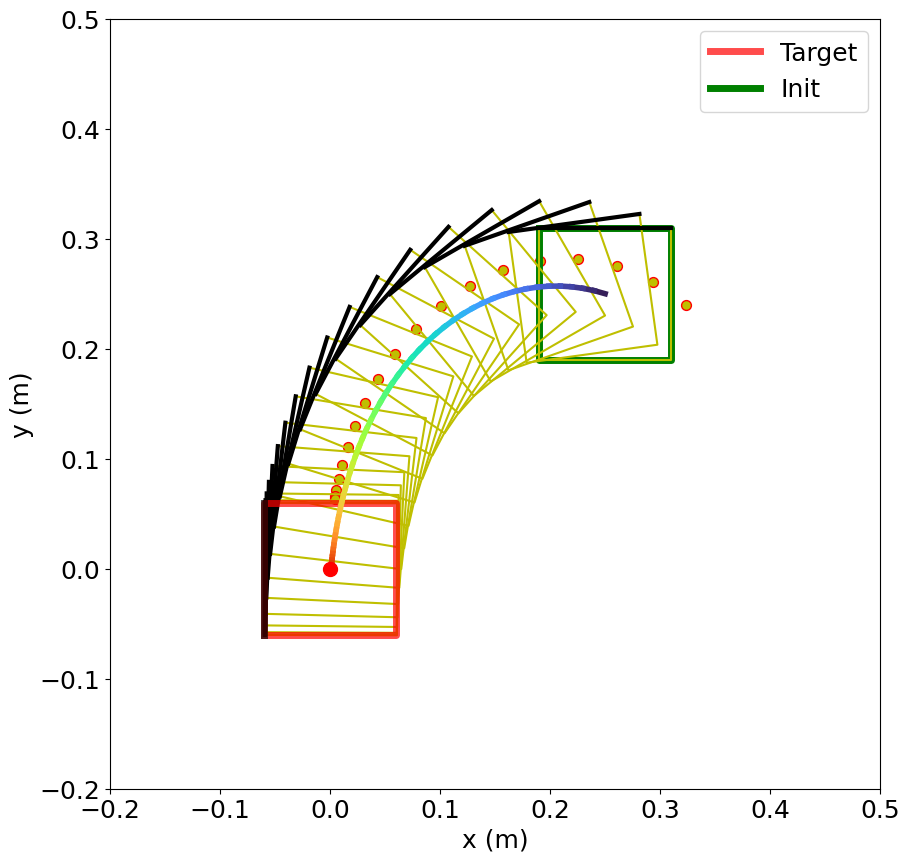

In [11]:
for i in range(len(traj)):
    plt = dyn_system.plot_planarpush_v2(traj[i:i+1].to('cpu').numpy(),
                        traj_actions[i:i+1].to('cpu').numpy(), x_target=p_target[0].to('cpu').numpy(),
                        animation=False, step_skip=3, 
                        xmax=w, figsize=10, 
                        save_as=None,
                        scale=10)
    plt.show()

In [10]:
#save and load traj and traj_actions
# torch.save(traj, cur_path +'/result/traj_mm.pt')
# torch.save(traj_actions, cur_path +'/result/traj_mm.pt')

traj = torch.load(cur_path+'/result/traj_mm.pt')
traj_actions = torch.load(cur_path+'/result/traj_actions_mm.pt')